# Effects of Semidiurnal Water Column Acidification and Sediment Presence on Growth and Survival of the Bivalve *Mya arenaria*

**Chapter 2 — Laboratory Experiment**  
**Associated publication:** McGarrigle, S.A. et al. Effects of semidiurnal water column acidification and sediment presence on growth and survival of the bivalve *Mya arenaria*. *Science of the Total Environment*. https://doi.org/10.1016/j.scitotenv.2022.158793  
**Language:** R

---

## Overview

This notebook contains the complete analysis pipeline for a laboratory experiment examining the effects of water column acidification regime and sediment presence on the growth and survival of soft-shell clam (*Mya arenaria*). A secondary species, the amphipod *Corophium volutator*, was also included in the experiment and is analysed here; this analysis was retained in the dissertation but not included in the published manuscript.

**Experimental design:**
- **Water treatments:** Control · Constant CO₂ (continuous acidification) · Intermittent CO₂ (semidiurnal acidification)
- **Sediment treatments:** In sediment · Above sediment
- **Randomisation unit:** Header tank (n = 9; Header 8 excluded — see Section 2)
- **Duration:** Summer 2019
- **Location:** Laboratory, University of New Brunswick

---

**Notebook structure:**
1. Setup and data loading
2. Data preparation
3. Water and sediment chemistry
4. *Mya arenaria* — growth and survival
5. *Corophium volutator* — growth and survival (thesis only)
6. Figures

---
*carbonate_chemistry_invertebrates/lab_experiment - Samantha McGarrigle*

## 1. Setup and Data Loading

In [27]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggpubr)
library(nlme)
library(lme4)
library(car)
library(multcomp)
library(rsq)

# All data files are in the data/ subfolder relative to this notebook.
# Set your working directory to lab_experiment/ before running.

clamLeng        <- read.csv("data/2019_clam_length.csv",            header = TRUE)
clamCombWeight  <- read.csv("data/2019_clam_combinedweights.csv",   header = TRUE)
clamIndivWeight <- read.csv("data/2019_clam_individualweights.csv", header = TRUE)
clamFeed        <- read.csv("data/2019_clam_feeding.csv",           header = TRUE)
coroLeng        <- read.csv("data/2019_coro_length.csv",            header = TRUE)
coroWeight      <- read.csv("data/2019_coro_weight.csv",            header = TRUE)
coroSurv        <- read.csv("data/2019_coro_survival.csv",          header = TRUE)
ph              <- read.csv("data/2019_ph.csv",                     header = TRUE)
sedpH           <- read.csv("data/2019_sedpH.csv",                  header = TRUE)
waterchem       <- read.csv("data/2019_waterchem.csv",              header = TRUE)

# The individual weights file has a column named 'Water _Trt' (space before
# underscore), which R reads as 'Water._Trt'. Rename to match all other files.
names(clamIndivWeight)[names(clamIndivWeight) == "Water._Trt"] <- "Water_Trt"

cat("Data loaded successfully\n")
cat("clam length rows:           ", nrow(clamLeng),        "\n")
cat("clam combined weight rows:  ", nrow(clamCombWeight),  "\n")
cat("clam individual weight rows:", nrow(clamIndivWeight), "\n")
cat("clam feeding rows:          ", nrow(clamFeed),        "\n")
cat("coro length rows:           ", nrow(coroLeng),        "\n")
cat("coro weight rows:           ", nrow(coroWeight),      "\n")
cat("coro survival rows:         ", nrow(coroSurv),        "\n")

# Trim whitespace from Water treatment columns across all files
# (trailing spaces from Excel/CSV export cause factor coding failures)
clamLeng$Water_Trt         <- trimws(clamLeng$Water_Trt)
clamCombWeight$Water_trt   <- trimws(clamCombWeight$Water_trt)
clamIndivWeight$Water_Trt  <- trimws(clamIndivWeight$Water_Trt)
clamFeed$Water_trt         <- trimws(clamFeed$Water_trt)
coroLeng$Water_Trt         <- trimws(coroLeng$Water_Trt)
coroWeight$Water_Trt       <- trimws(coroWeight$Water_Trt)
coroSurv$Water_Trt         <- trimws(coroSurv$Water_Trt)
ph$Water_Trt               <- trimws(ph$Water_Trt)

Data loaded successfully
clam length rows:            1484 
clam combined weight rows:   108 
clam individual weight rows: 731 
clam feeding rows:           30 
coro length rows:            352 
coro weight rows:            54 
coro survival rows:          54 


## 2. Data Preparation

### Header 8 exclusion
Header tank 8 (Constant CO₂ treatment) is excluded from all primary analyses. The pH manipulation system for this header tank failed for a period during the experiment, compromising treatment integrity. All datasets excluding Header 8 are denoted with the suffix `3` (three remaining header tanks per treatment).

### Treatment level naming
Factor levels are renamed from the raw data coding (`Control`, `Acidified`, `Variable`) to the published terminology (`Control`, `Constant CO2`, `Intermittent CO2`).

### Initial lengths
Initial shell length measurements are extracted from `clamLeng` where `Timing == "Start"`. Standardised (size-adjusted) initial lengths (`Adj_Length`) are in the same file.

In [28]:
# ── Published treatment level names ──────────────────────────────────────────
trt_levels_orig <- c("Control", "Acidified", "Variable")
trt_levels_pub  <- c("Control", "Constant CO2", "Intermittent CO2")

# Helper: set factor levels and rename to published terminology
set_water_trt <- function(df, col, orig = trt_levels_orig, pub = trt_levels_pub) {
  df[[col]] <- factor(df[[col]], levels = orig)
  levels(df[[col]]) <- pub
  df
}

# ── Factor coding — Mya arenaria data ────────────────────────────────────────
clamLeng <- set_water_trt(clamLeng, "Water_Trt")
clamLeng$Header     <- as.factor(clamLeng$Header)
clamLeng$Container  <- as.factor(clamLeng$Container)
clamLeng$Animal_Rep <- as.factor(clamLeng$Animal_Rep)

clamCombWeight <- set_water_trt(clamCombWeight, "Water_trt")
clamCombWeight$Header     <- as.factor(clamCombWeight$Header)
clamCombWeight$Container  <- as.factor(clamCombWeight$Container)
clamCombWeight$Animal_Rep <- as.factor(clamCombWeight$Animal_Rep)

clamIndivWeight <- set_water_trt(clamIndivWeight, "Water_Trt")
clamIndivWeight$Header     <- as.factor(clamIndivWeight$Header)
clamIndivWeight$Container  <- as.factor(clamIndivWeight$Container)
clamIndivWeight$Animal_Rep <- as.factor(clamIndivWeight$Animal_Rep)

# Feeding has four levels including Blank
clamFeed$Water_trt  <- factor(clamFeed$Water_trt, levels = c("Blank", trt_levels_orig))
levels(clamFeed$Water_trt) <- c("Blank", trt_levels_pub)
clamFeed$Header     <- as.factor(clamFeed$Header)
clamFeed$Animal_Rep <- as.factor(clamFeed$Animal_Rep)
clamFeed$Container  <- as.factor(clamFeed$Container)

# ── Factor coding — Corophium volutator data ──────────────────────────────────
coroLeng   <- set_water_trt(coroLeng,   "Water_Trt")
coroWeight <- set_water_trt(coroWeight, "Water_Trt")
coroSurv   <- set_water_trt(coroSurv,   "Water_Trt")
coroLeng$Header   <- as.factor(coroLeng$Header)
coroWeight$Header <- as.factor(coroWeight$Header)
coroSurv$Header   <- as.factor(coroSurv$Header)

cat("Factor levels set\n")
cat("Water treatment levels:", levels(clamLeng$Water_Trt), "\n")

Factor levels set
Water treatment levels: Control Constant CO2 Intermittent CO2 


In [29]:
# ── Timing subsets ────────────────────────────────────────────────────────────
MyaLengStart    <- filter(clamLeng,       Timing == "Start")
MyaLengFin      <- filter(clamLeng,       Timing == "End")
MyaCombWeighFin <- filter(clamCombWeight, Timing == "End")

# ── Header 8 excluded subsets (primary analysis) ──────────────────────────────
MyaLengStart3    <- filter(MyaLengStart,    Header != "8")
MyaLengFin3      <- filter(MyaLengFin,      Header != "8")
MyaCombWeighFin3 <- filter(MyaCombWeighFin, Header != "8")
clamIndivWeight3 <- filter(clamIndivWeight, Header != "8")
clamFeed3        <- filter(clamFeed,        Header != "8")
coroLeng3        <- filter(coroLeng,        Header != "8")
coroWeight3      <- filter(coroWeight,      Header != "8")
coroSurv3        <- filter(coroSurv,        Header != "8")

# ── Interaction term (Water × Sediment) for post-hoc tests ───────────────────
MyaLengStart3$WaterSed    <- interaction(MyaLengStart3$Water_Trt,    MyaLengStart3$Sed_Trt)
MyaLengFin3$WaterSed      <- interaction(MyaLengFin3$Water_Trt,      MyaLengFin3$Sed_Trt)
MyaCombWeighFin3$WaterSed <- interaction(MyaCombWeighFin3$Water_trt, MyaCombWeighFin3$Sed_trt)
clamIndivWeight3$WaterSed <- interaction(clamIndivWeight3$Water_Trt, clamIndivWeight3$Sed_Trt)

cat("Subsets created\n")
cat("MyaLengFin3 rows (Header 8 excluded):", nrow(MyaLengFin3), "\n")
cat("Headers present:", paste(levels(droplevels(MyaLengFin3$Header)), collapse = " "), "\n")

Subsets created
MyaLengFin3 rows (Header 8 excluded): 646 
Headers present: 1 2 3 4 5 6 7 9 


## 3. Water and Sediment Chemistry

Water chemistry was characterised using two approaches:
- **Daily pH** (`2019_ph`): handheld measurements calibrated against TRIS buffer, recorded at multiple timepoints per day to capture diel variation across treatments
- **Carbonate chemistry** (`2019_waterchem`): discrete water samples sent for full dissolved inorganic carbon analysis (TA, pCO₂, pH, CO₂, HCO₃, CO₃, calcite and aragonite saturation state)
- **Sediment pH** (`2019_sedpH`): measured throughout the experiment

In [30]:
# ── Factor coding — chemistry data ───────────────────────────────────────────
ph <- set_water_trt(ph, "Water_Trt")
ph$Date      <- as.factor(ph$Date)
ph$Header    <- as.factor(ph$Header)
ph$Water_Rep <- as.factor(ph$Water_Rep)

sedpH$Water_Trt  <- as.factor(sedpH$Water_Trt)
sedpH$Water_Rep  <- as.factor(sedpH$Water_Rep)
sedpH$Date       <- as.factor(sedpH$Date)

waterchem$Water_trt <- as.factor(waterchem$Water_trt)
waterchem$Tank      <- as.factor(waterchem$Tank)
waterchem$Bottle    <- as.factor(waterchem$Bottle)
waterchem$Date      <- as.factor(waterchem$Date)

# Standardise treatment names in waterchem to match published terminology
waterchem$Water_trt <- dplyr::recode(waterchem$Water_trt,
                                      `Variable`  = "Intermittent CO2",
                                      `Acidified` = "Constant CO2")

In [31]:
# ── Daily pH summary by treatment ────────────────────────────────────────────
ph %>%
  group_by(Water_Trt) %>%
  summarise(
    mean_pH = mean(pH_TRIS, na.rm = TRUE),
    sd_pH   = sd(pH_TRIS,   na.rm = TRUE),
    n       = n(),
    .groups = "drop"
  )

Water_Trt,mean_pH,sd_pH,n
<fct>,<dbl>,<dbl>,<int>
Control,7.950504,0.05988428,258
Constant CO2,7.729302,0.13213415,258
Intermittent CO2,7.811008,0.16181771,258


In [32]:
# ── pH time series — representative measurement date ─────────────────────────
# Summarise pH by treatment and time for a single representative date.
# Update target_date to match the date used in the manuscript figure.
target_date <- levels(ph$Date)[1]

ph_day_summary <- ph %>%
  filter(Date == target_date) %>%
  group_by(Water_Trt, Time) %>%
  summarise(
    mean_pH = mean(pH_TRIS, na.rm = TRUE),
    sd_pH   = sd(pH_TRIS,   na.rm = TRUE),
    .groups = "drop"
  )

print(ph_day_summary)

# A tibble: 12 × 4
   Water_Trt         Time mean_pH   sd_pH
   <fct>            <int>   <dbl>   <dbl>
 1 Control            845    7.88 0.01000
 2 Control           1000    7.88 0.00577
 3 Control           1540    7.87 0.0115 
 4 Control           1600    7.87 0.0153 
 5 Constant CO2       845    7.71 0.100  
 6 Constant CO2      1000    7.63 0.129  
 7 Constant CO2      1540    7.66 0.0902 
 8 Constant CO2      1600    7.66 0.110  
 9 Intermittent CO2   845    7.36 0.574  
10 Intermittent CO2  1000    7.74 0.0529 
11 Intermittent CO2  1540    7.87 0.00577
12 Intermittent CO2  1600    7.49 0.127  


In [33]:
# ── Carbonate chemistry summary by treatment ──────────────────────────────────
waterchem %>%
  group_by(Water_trt) %>%
  summarise(
    across(
      c(TA, pCO2, pH_meas, pH_calc, CO2, HCO3, CO3, Calcite, Arag),
      list(mean = ~ mean(.x, na.rm = TRUE),
           sd   = ~ sd(.x,   na.rm = TRUE))
    ),
    .groups = "drop"
  )

Water_trt,TA_mean,TA_sd,pCO2_mean,pCO2_sd,pH_meas_mean,pH_meas_sd,pH_calc_mean,pH_calc_sd,CO2_mean,CO2_sd,HCO3_mean,HCO3_sd,CO3_mean,CO3_sd,Calcite_mean,Calcite_sd,Arag_mean,Arag_sd
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Constant CO2,2174.071,23.07269,2871.919,1201.3923,7.690833,0.10184885,7.377167,0.1470234,112.43375,47.90667,2106.268,36.55673,27.21750,7.609226,0.6583333,0.1839581,0.4204167,0.1169719
Control,2174.475,41.89916,1887.557,836.7174,7.967083,0.06583769,7.556125,0.1515971,73.52750,31.65958,2073.699,57.95925,40.43375,11.404425,0.9775000,0.2753535,0.6241667,0.1745283
Intermittent CO2,2159.043,35.88363,2139.565,631.5615,7.790833,0.13448506,7.490083,0.1329429,83.08042,22.83455,2073.110,42.58706,34.43292,10.024403,0.8325000,0.2407642,0.5304167,0.1522435


In [34]:
# ── Total alkalinity — LME by water treatment ─────────────────────────────────
TA_mod <- lme(TA ~ Water_trt,
              random    = ~ 1 | Water_rep,
              na.action = na.exclude,
              data      = waterchem)
anova(TA_mod)

,numDF,denDF,F-value,p-value
,<int>,<dbl>,<dbl>,<dbl>
(Intercept),1,67,1.308028e+05,0.000000
Water_trt,2,67,1.614251e+00,0.206684


In [35]:
# ── pCO2 — LMER by water treatment ───────────────────────────────────────────
pCO2_mod <- lmer(pCO2 ~ Water_trt + (1 | Date),
                 na.action = na.exclude,
                 data      = waterchem)
car::Anova(pCO2_mod)

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
Water_trt,15.61624,2,0.0004064223


## 4. *Mya arenaria* — Growth and Survival

All growth models use generalised linear mixed models (GLMMs) with a Gamma distribution and inverse link, appropriate for positive continuous measurements (lengths, weights). Survival (number recovered) is modelled with LME. Header tank is included as a random effect, with Container nested within Header.

Post-hoc comparisons use Tukey's method via `multcomp::glht` applied to the Water × Sediment interaction term.

**Fixed effects:** Water treatment × Sediment treatment  
**Random effects:** (1 | Header / Container)

In [37]:
# ── Initial shell length — verify no differences at experiment start ───────────
# Uses raw shell length from Start timing rows
initlength_mod <- lme(Length ~ Water_Trt * Sed_Trt,
                      random    = ~ 1 | Header / Container,
                      na.action = na.exclude,
                      data      = MyaLengStart3)
anova(initlength_mod)

initlength_posthoc <- lme(Length ~ WaterSed,
                          random = ~ 1 | Header / Container,
                          data   = MyaLengStart3)
summary(glht(initlength_posthoc, linfct = mcp(WaterSed = "Tukey")))

,numDF,denDF,F-value,p-value
,<int>,<dbl>,<dbl>,<dbl>
(Intercept),1,646,7408.2631206,0.0000000
Water_Trt,2,5,1.1128942,0.3983015
Sed_Trt,1,646,0.5123801,0.4743690
Water_Trt:Sed_Trt,2,646,4.1382297,0.0163759



	 Simultaneous Tests for General Linear Hypotheses

Multiple Comparisons of Means: Tukey Contrasts


Fit: lme.formula(fixed = Length ~ WaterSed, data = MyaLengStart3, 
    random = ~1 | Header/Container)

Linear Hypotheses:
                                                 Estimate Std. Error z value
Constant CO2.In - Control.In == 0               -0.506984   0.223835  -2.265
Intermittent CO2.In - Control.In == 0            0.091004   0.199921   0.455
Control.Out - Control.In == 0                   -0.126270   0.170968  -0.739
Constant CO2.Out - Control.In == 0               0.088016   0.223835   0.393
Intermittent CO2.Out - Control.In == 0           0.020873   0.200204   0.104
Intermittent CO2.In - Constant CO2.In == 0       0.597988   0.223582   2.675
Control.Out - Constant CO2.In == 0               0.380714   0.223835   1.701
Constant CO2.Out - Constant CO2.In == 0          0.595000   0.209392   2.842
Intermittent CO2.Out - Constant CO2.In == 0      0.527857   0.223835   2.358
Contr

In [38]:
# ── Final shell length ────────────────────────────────────────────────────────
length_mod <- glmer(Length ~ Water_Trt * Sed_Trt + (1 | Header / Container),
                    family = Gamma(link = "inverse"),
                    data   = MyaLengFin3)
car::Anova(length_mod, type = 3)

length_posthoc <- glmer(Length ~ WaterSed + (1 | Header / Container),
                        family = Gamma(link = "inverse"),
                        data   = MyaLengFin3)
summary(glht(length_posthoc, linfct = mcp(WaterSed = "Tukey")))

MyaLengFin3 %>%
  group_by(Water_Trt, Sed_Trt) %>%
  summarise(mean = mean(Length, na.rm = TRUE),
            sd   = sd(Length,   na.rm = TRUE),
            n    = n(), .groups = "drop")

boundary (singular) fit: see help('isSingular')



,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),1488.87350,1,0.000000e+00
Water_Trt,28.77454,2,5.645301e-07
Sed_Trt,33.93059,1,5.711361e-09
Water_Trt:Sed_Trt,24.74017,2,4.243666e-06


boundary (singular) fit: see help('isSingular')




	 Simultaneous Tests for General Linear Hypotheses

Multiple Comparisons of Means: Tukey Contrasts


Fit: glmer(formula = Length ~ WaterSed + (1 | Header/Container), data = MyaLengFin3, 
    family = Gamma(link = "inverse"))

Linear Hypotheses:
                                                  Estimate Std. Error z value
Constant CO2.In - Control.In == 0                0.0325369  0.0066060   4.925
Intermittent CO2.In - Control.In == 0            0.0002221  0.0052447   0.042
Control.Out - Control.In == 0                    0.0267009  0.0045844   5.824
Constant CO2.Out - Control.In == 0               0.0228218  0.0062139   3.673
Intermittent CO2.Out - Control.In == 0           0.0239979  0.0055550   4.320
Intermittent CO2.In - Constant CO2.In == 0      -0.0323147  0.0065734  -4.916
Control.Out - Constant CO2.In == 0              -0.0058360  0.0068298  -0.854
Constant CO2.Out - Constant CO2.In == 0         -0.0097150  0.0062757  -1.548
Intermittent CO2.Out - Constant CO2.In == 0     -0.0

Water_Trt,Sed_Trt,mean,sd,n
<fct>,<chr>,<dbl>,<dbl>,<int>
Control,In,6.944538,1.436787,119
Control,Out,5.862400,1.409625,125
Constant CO2,In,5.688889,1.282884,72
Constant CO2,Out,6.027711,1.679163,83
Intermittent CO2,In,6.941600,1.538390,125
Intermittent CO2,Out,5.955738,1.324845,122


In [39]:
# ── Final shell width ─────────────────────────────────────────────────────────
width_mod <- glmer(Width ~ Water_Trt * Sed_Trt + (1 | Header / Container),
                   family = Gamma(link = "inverse"),
                   data   = MyaLengFin3)
car::Anova(width_mod, type = 3)

width_posthoc <- glmer(Width ~ WaterSed + (1 | Header / Container),
                       family = Gamma(link = "inverse"),
                       data   = MyaLengFin3)
summary(glht(width_posthoc, linfct = mcp(WaterSed = "Tukey")))

boundary (singular) fit: see help('isSingular')



,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),1503.46024,1,0.000000e+00
Water_Trt,32.86909,2,7.287320e-08
Sed_Trt,31.53836,1,1.955389e-08
Water_Trt:Sed_Trt,22.18175,2,1.525082e-05


boundary (singular) fit: see help('isSingular')




	 Simultaneous Tests for General Linear Hypotheses

Multiple Comparisons of Means: Tukey Contrasts


Fit: glmer(formula = Width ~ WaterSed + (1 | Header/Container), data = MyaLengFin3, 
    family = Gamma(link = "inverse"))

Linear Hypotheses:
                                                  Estimate Std. Error z value
Constant CO2.In - Control.In == 0                0.0571879  0.0108614   5.265
Intermittent CO2.In - Control.In == 0            0.0003719  0.0086031   0.043
Control.Out - Control.In == 0                    0.0412002  0.0073377   5.615
Constant CO2.Out - Control.In == 0               0.0434243  0.0102671   4.229
Intermittent CO2.Out - Control.In == 0           0.0398463  0.0090976   4.380
Intermittent CO2.In - Constant CO2.In == 0      -0.0568160  0.0108089  -5.256
Control.Out - Constant CO2.In == 0              -0.0159877  0.0111867  -1.429
Constant CO2.Out - Constant CO2.In == 0         -0.0137636  0.0102674  -1.341
Intermittent CO2.Out - Constant CO2.In == 0     -0.01

In [40]:
# ── Dry shell weight ──────────────────────────────────────────────────────────
dryshell_mod <- glmer(Shell_dry ~ Water_Trt * Sed_Trt + (1 | Header / Container),
                      family = Gamma(link = "inverse"),
                      data   = clamIndivWeight3)
car::Anova(dryshell_mod, type = 3)

dryshell_posthoc <- glmer(Shell_dry ~ WaterSed + (1 | Header / Container),
                          family = Gamma(link = "inverse"),
                          data   = clamIndivWeight3)
summary(glht(dryshell_posthoc, linfct = mcp(WaterSed = "Tukey")))

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),279.984735,1,7.566979e-63
Water_Trt,31.493558,2,1.449642e-07
Sed_Trt,7.466304,1,6.286450e-03
Water_Trt:Sed_Trt,19.879635,2,4.821609e-05



	 Simultaneous Tests for General Linear Hypotheses

Multiple Comparisons of Means: Tukey Contrasts


Fit: glmer(formula = Shell_dry ~ WaterSed + (1 | Header/Container), 
    data = clamIndivWeight3, family = Gamma(link = "inverse"))

Linear Hypotheses:
                                                Estimate Std. Error z value
Constant CO2.In - Control.In == 0                50.4440    10.6299   4.746
Intermittent CO2.In - Control.In == 0            -4.3882     7.2744  -0.603
Control.Out - Control.In == 0                    16.6228     6.3406   2.622
Constant CO2.Out - Control.In == 0               21.0855     8.8755   2.376
Intermittent CO2.Out - Control.In == 0           16.3044     7.9153   2.060
Intermittent CO2.In - Constant CO2.In == 0      -54.8323    10.4256  -5.259
Control.Out - Constant CO2.In == 0              -33.8212    10.8667  -3.112
Constant CO2.Out - Constant CO2.In == 0         -29.3586    10.2461  -2.865
Intermittent CO2.Out - Constant CO2.In == 0     -34.1396    10

In [41]:
# ── Dry tissue weight ─────────────────────────────────────────────────────────
drytissue_mod <- glmer(Tissue_dry ~ Water_Trt * Sed_Trt + (1 | Header / Container),
                       family = Gamma(link = "inverse"),
                       data   = clamIndivWeight3)
car::Anova(drytissue_mod, type = 3)

drytissue_posthoc <- glmer(Tissue_dry ~ WaterSed + (1 | Header / Container),
                           family = Gamma(link = "inverse"),
                           data   = clamIndivWeight3)
summary(glht(drytissue_posthoc, linfct = mcp(WaterSed = "Tukey")))

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),1523.9279,1,0.000000e+00
Water_Trt,814.2086,2,1.573443e-177
Sed_Trt,294.6821,1,4.746787e-66
Water_Trt:Sed_Trt,578.7629,2,2.104940e-126


Warning message in RET$pfunction("adjusted", ...):
"Completion with error > abseps"



	 Simultaneous Tests for General Linear Hypotheses

Multiple Comparisons of Means: Tukey Contrasts


Fit: glmer(formula = Tissue_dry ~ WaterSed + (1 | Header/Container), 
    data = clamIndivWeight3, family = Gamma(link = "inverse"))

Linear Hypotheses:
                                                Estimate Std. Error z value
Constant CO2.In - Control.In == 0                 658.71      28.61  23.027
Intermittent CO2.In - Control.In == 0            -113.23      28.97  -3.908
Control.Out - Control.In == 0                     391.02      23.01  16.992
Constant CO2.Out - Control.In == 0                476.48      25.31  18.822
Intermittent CO2.Out - Control.In == 0            231.63      30.20   7.669
Intermittent CO2.In - Constant CO2.In == 0       -771.95      40.75 -18.943
Control.Out - Constant CO2.In == 0               -267.69      39.90  -6.709
Constant CO2.Out - Constant CO2.In == 0          -182.23      37.29  -4.886
Intermittent CO2.Out - Constant CO2.In == 0      -427.09     

In [42]:
# ── Total dry weight ──────────────────────────────────────────────────────────
drytotal_mod <- glmer(Total_dry ~ Water_Trt * Sed_Trt + (1 | Header / Container),
                      family = Gamma(link = "inverse"),
                      data   = clamIndivWeight3)
car::Anova(drytotal_mod, type = 3)

drytotal_posthoc <- glmer(Total_dry ~ WaterSed + (1 | Header / Container),
                          family = Gamma(link = "inverse"),
                          data   = clamIndivWeight3)
summary(glht(drytotal_posthoc, linfct = mcp(WaterSed = "Tukey")))

# Summary statistics for all three dry weight measures
clamIndivWeight3 %>%
  group_by(Water_Trt, Sed_Trt) %>%
  summarise(
    across(c(Shell_dry, Tissue_dry, Total_dry),
           list(mean = ~ mean(.x, na.rm = TRUE),
                sd   = ~ sd(.x,   na.rm = TRUE))),
    n = n(), .groups = "drop"
  )

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),229.936991,1,6.152955e-52
Water_Trt,20.164530,2,4.181460e-05
Sed_Trt,8.376598,1,3.800832e-03
Water_Trt:Sed_Trt,12.700855,2,1.746000e-03



	 Simultaneous Tests for General Linear Hypotheses

Multiple Comparisons of Means: Tukey Contrasts


Fit: glmer(formula = Total_dry ~ WaterSed + (1 | Header/Container), 
    data = clamIndivWeight3, family = Gamma(link = "inverse"))

Linear Hypotheses:
                                                Estimate Std. Error z value
Constant CO2.In - Control.In == 0                 43.811     10.478   4.181
Intermittent CO2.In - Control.In == 0             -4.128      6.856  -0.602
Control.Out - Control.In == 0                     16.746      5.810   2.882
Constant CO2.Out - Control.In == 0                21.717      8.521   2.549
Intermittent CO2.Out - Control.In == 0            15.152      7.539   2.010
Intermittent CO2.In - Constant CO2.In == 0       -47.939     10.511  -4.561
Control.Out - Constant CO2.In == 0               -27.065     10.841  -2.497
Constant CO2.Out - Constant CO2.In == 0          -22.094     10.307  -2.144
Intermittent CO2.Out - Constant CO2.In == 0      -28.660     1

Water_Trt,Sed_Trt,Shell_dry_mean,Shell_dry_sd,Tissue_dry_mean,Tissue_dry_sd,Total_dry_mean,Total_dry_sd,n
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Control,In,0.011756780,0.005959873,0.0011368421,0.0007800911,0.01301930,0.006643100,118
Control,Out,0.009827200,0.005530420,0.0007822581,0.0005571484,0.01066694,0.005930707,125
Constant CO2,In,0.007388312,0.003928974,0.0006444444,0.0004644602,0.00825000,0.004358931,77
Constant CO2,Out,0.009436585,0.006358673,0.0007414634,0.0006701670,0.01017805,0.006960258,82
Intermittent CO2,In,0.012369919,0.008182918,0.0013756098,0.0013759850,0.01374553,0.009046168,123
Intermittent CO2,Out,0.009763415,0.004902797,0.0009068376,0.0014412475,0.01075726,0.005613443,123


In [43]:
# ── Survival (number of clams recovered at experiment end) ────────────────────
surv_mod <- lme(Indiv ~ Water_trt * Sed_trt,
                random    = ~ 1 | Header,
                na.action = na.exclude,
                data      = MyaCombWeighFin3)
anova(surv_mod, type = "marginal")

surv_posthoc <- lme(Indiv ~ WaterSed,
                    random = ~ 1 | Header,
                    data   = MyaCombWeighFin3)
summary(glht(surv_posthoc, linfct = mcp(WaterSed = "Tukey")))

MyaCombWeighFin3 %>%
  group_by(Water_trt, Sed_trt) %>%
  summarise(mean = mean(Indiv, na.rm = TRUE),
            sd   = sd(Indiv,   na.rm = TRUE),
            n    = n(), .groups = "drop")

,numDF,denDF,F-value,p-value
,<int>,<dbl>,<dbl>,<dbl>
(Intercept),1,37,625.07829,0.0000000000
Water_trt,2,5,17.61495,0.0054456864
Sed_trt,1,37,0.00000,1.0000000000
Water_trt:Sed_trt,2,37,10.63932,0.0002237731



	 Simultaneous Tests for General Linear Hypotheses

Multiple Comparisons of Means: Tukey Contrasts


Fit: lme.formula(fixed = Indiv ~ WaterSed, data = MyaCombWeighFin3, 
    random = ~1 | Header)

Linear Hypotheses:
                                                  Estimate Std. Error z value
Constant CO2.In - Control.In == 0               -4.056e+00  8.362e-01  -4.850
Intermittent CO2.In - Control.In == 0            6.667e-01  7.479e-01   0.891
Control.Out - Control.In == 0                    7.594e-16  7.479e-01   0.000
Constant CO2.Out - Control.In == 0               4.444e-01  8.362e-01   0.532
Intermittent CO2.Out - Control.In == 0          -5.234e-17  7.479e-01   0.000
Intermittent CO2.In - Constant CO2.In == 0       4.722e+00  8.362e-01   5.647
Control.Out - Constant CO2.In == 0               4.056e+00  8.362e-01   4.850
Constant CO2.Out - Constant CO2.In == 0          4.500e+00  9.160e-01   4.913
Intermittent CO2.Out - Constant CO2.In == 0      4.056e+00  8.362e-01   4.850
Con

Water_trt,Sed_trt,mean,sd,n
<fct>,<chr>,<dbl>,<dbl>,<int>
Control,In,13.222222,1.9860625,9
Control,Out,13.222222,1.3944334,9
Constant CO2,In,9.166667,2.9268869,6
Constant CO2,Out,13.666667,0.8164966,6
Intermittent CO2,In,13.888889,0.6009252,9
Intermittent CO2,Out,13.222222,1.0929064,9


In [44]:
# ── Feeding rate ──────────────────────────────────────────────────────────────
feed_mod <- lme(Rate ~ Water_trt,
                random    = ~ 1 | Header,
                na.action = na.exclude,
                data      = clamFeed3)
anova(feed_mod, type = "marginal")

clamFeed3 %>%
  group_by(Water_trt) %>%
  summarise(mean = mean(Rate, na.rm = TRUE),
            sd   = sd(Rate,   na.rm = TRUE),
            n    = n(), .groups = "drop")

,numDF,denDF,F-value,p-value
,<int>,<dbl>,<dbl>,<dbl>
(Intercept),1,18,0.6998732,0.4137953
Water_trt,3,5,0.3421888,0.7967541


Water_trt,mean,sd,n
<fct>,<dbl>,<dbl>,<int>
Blank,6677.778,5693.694,3
Control,11185.556,12039.198,9
Constant CO2,12025.000,10248.255,6
Intermittent CO2,5970.000,6261.208,9


## 5. *Corophium volutator* — Growth and Survival

**Note:** The *Corophium volutator* analysis was included in the dissertation (Chapter 2) but was not included in the associated published manuscript. It is retained here for completeness.

*C. volutator* were only measured at the end of the experiment. The design for this species includes Water treatment × Source population (two collection sites).

In [45]:
# ── Corophium body length ─────────────────────────────────────────────────────
corolength_mod <- glmer(Length ~ Water_Trt * Population + (1 | Header),
                        family = Gamma(link = "inverse"),
                        data   = coroLeng3)
car::Anova(corolength_mod, type = 3)

coroLeng3 %>%
  group_by(Water_Trt, Population) %>%
  summarise(mean = mean(Length, na.rm = TRUE),
            sd   = sd(Length,   na.rm = TRUE),
            n    = n(), .groups = "drop")

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),795.247153,1,5.826658e-175
Water_Trt,3.499606,2,1.738082e-01
Population,3.315590,1,6.862570e-02
Water_Trt:Population,10.725194,2,4.688714e-03


Water_Trt,Population,mean,sd,n
<fct>,<chr>,<dbl>,<dbl>,<int>
Control,Lower,6.131148,0.7187120,61
Control,Upper,5.705538,0.9940605,65
Constant CO2,Lower,5.424286,0.7332296,21
Constant CO2,Upper,5.690333,0.8290563,30
Intermittent CO2,Lower,6.167015,0.8285182,67
Intermittent CO2,Upper,5.616111,0.8778664,72


In [46]:
# ── Corophium weight ──────────────────────────────────────────────────────────
coroweight_mod <- glmer(Weight ~ Water_Trt * Population + (1 | Header),
                        family = Gamma(link = "inverse"),
                        data   = coroWeight3)
car::Anova(coroweight_mod, type = 3)

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),7.202792399,1,0.007279023
Water_Trt,3.156438555,2,0.206342209
Population,0.001232438,1,0.971995137
Water_Trt:Population,1.302169253,2,0.521479859


In [47]:
# ── Corophium survival ────────────────────────────────────────────────────────
corosurv_mod <- lme(Indiv_End ~ Water_Trt * Population,
                    random    = ~ 1 | Header,
                    na.action = na.exclude,
                    data      = coroSurv3)
car::Anova(corosurv_mod, type = 3)

coroSurv3 %>%
  group_by(Water_Trt, Population) %>%
  summarise(mean_n        = mean(Indiv_End, na.rm = TRUE),
            mean_surv_pct = mean(Surv__All, na.rm = TRUE),
            n             = n(), .groups = "drop")

,Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
(Intercept),9.77785203,1,0.001766265
Water_Trt,1.43507913,2,0.487951353
Population,0.03546713,1,0.850620182
Water_Trt:Population,0.09088451,2,0.955574781


Water_Trt,Population,mean_n,mean_surv_pct,n
<fct>,<chr>,<dbl>,<dbl>,<int>
Control,Lower,6.777778,20.53872,9
Control,Upper,7.222222,21.88552,9
Constant CO2,Lower,3.500000,10.60606,6
Constant CO2,Upper,5.000000,15.15152,6
Intermittent CO2,Lower,7.444444,22.55892,9
Intermittent CO2,Upper,8.000000,24.24242,9


## 6. Figures

All figures use `theme_classic` with greyscale fills and CO₂ subscript expression labels matching the published manuscript style. Multi-panel figures are arranged using `ggpubr::ggarrange`.

In [61]:
# ── Shared plot elements ──────────────────────────────────────────────────────
water_trt_labels <- c(
  expression(Control),
  expression(Constant~CO[2]),
  expression(Intermittent~CO[2])
)
grey_fill  <- scale_fill_grey(start = 0.5, end = 1.0)
grey_color <- scale_color_grey(start = 0.2, end = 0.7)
base_theme <- theme_classic(base_size = 20)

options(repr.plot.width = 15, repr.plot.height = 6)

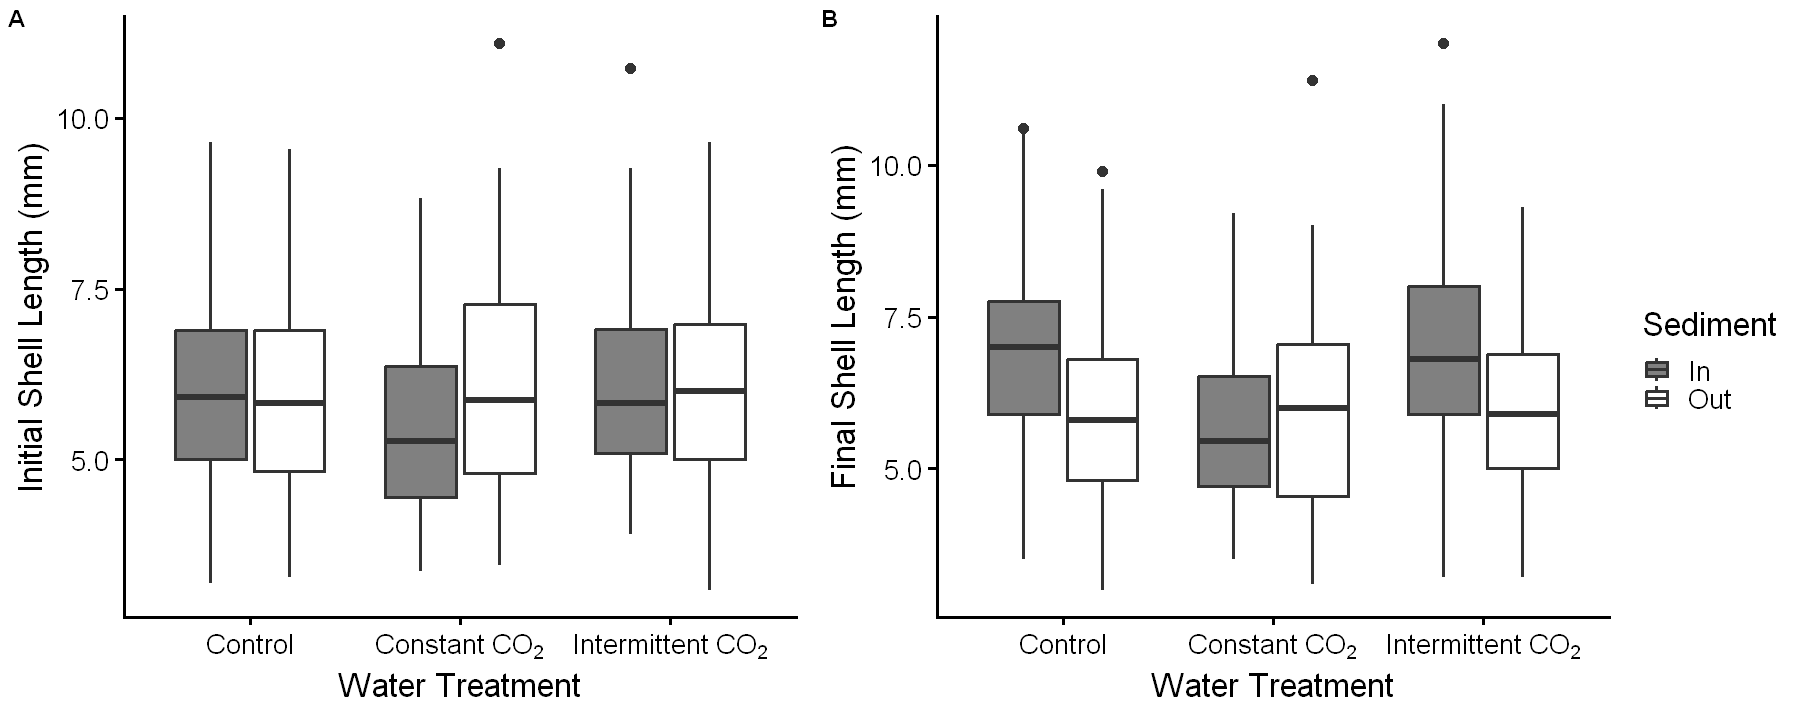

In [62]:
# ── Figure 1: Initial and final shell length ──────────────────────────────────
fig_init <- ggplot(MyaLengStart3, aes(x = Water_Trt, y = Length, fill = Sed_Trt)) +
  geom_boxplot() +
  labs(x = "Water Treatment", y = "Initial Shell Length (mm)", fill = "Sediment") +
  scale_x_discrete(labels = water_trt_labels) +
  grey_fill + base_theme

fig_length <- ggplot(MyaLengFin3, aes(x = Water_Trt, y = Length, fill = Sed_Trt)) +
  geom_boxplot() +
  labs(x = "Water Treatment", y = "Final Shell Length (mm)", fill = "Sediment") +
  scale_x_discrete(labels = water_trt_labels) +
  grey_fill + base_theme

ggarrange(fig_init, fig_length,
          labels        = c("A", "B"),
          common.legend = TRUE,
          legend        = "right")

Warning message:
"Removed 34 rows containing non-finite outside the scale range
(`stat_boxplot()`)."
Warning message:
"Removed 34 rows containing non-finite outside the scale range
(`stat_boxplot()`)."
Warning message:
"Removed 34 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


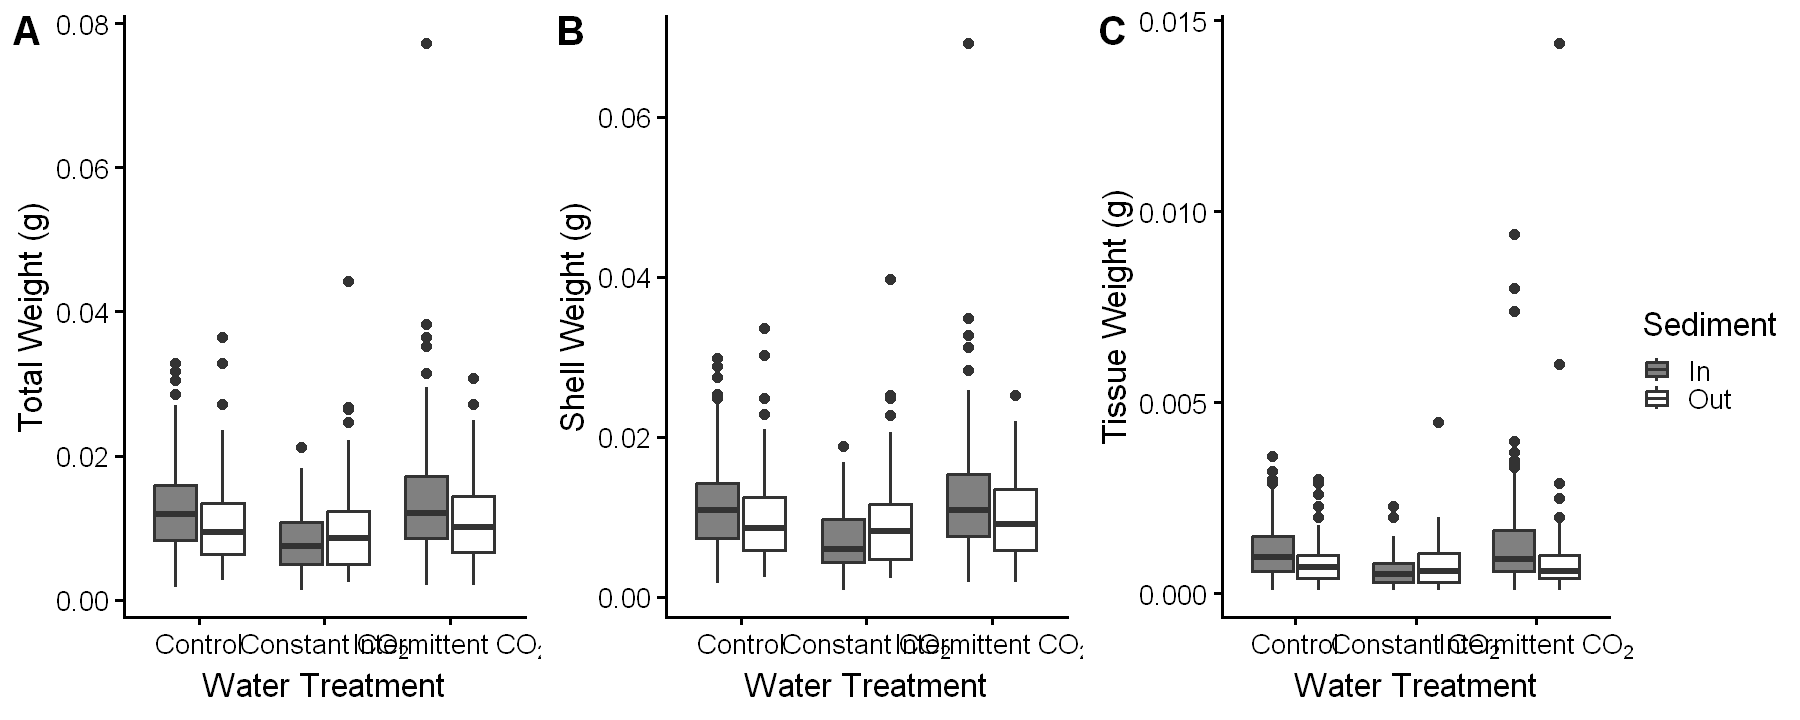

In [63]:
# ── Figure 2: Dry weights — total, shell, tissue ──────────────────────────────
fig_drytotal <- ggplot(clamIndivWeight3, aes(x = Water_Trt, y = Total_dry, fill = Sed_Trt)) +
  geom_boxplot() +
  labs(x = "Water Treatment", y = "Total Weight (g)", fill = "Sediment") +
  scale_x_discrete(labels = water_trt_labels) +
  grey_fill + base_theme

fig_dryshell <- ggplot(clamIndivWeight3, aes(x = Water_Trt, y = Shell_dry, fill = Sed_Trt)) +
  geom_boxplot() +
  labs(x = "Water Treatment", y = "Shell Weight (g)", fill = "Sediment") +
  scale_x_discrete(labels = water_trt_labels) +
  grey_fill + base_theme

fig_drytissue <- ggplot(clamIndivWeight3, aes(x = Water_Trt, y = Tissue_dry, fill = Sed_Trt)) +
  geom_boxplot() +
  labs(x = "Water Treatment", y = "Tissue Weight (g)", fill = "Sediment") +
  scale_x_discrete(labels = water_trt_labels) +
  grey_fill + base_theme

ggarrange(fig_drytotal, fig_dryshell, fig_drytissue,
          ncol          = 3,
          nrow          = 1,
          labels        = c("A", "B", "C"),
          font.label    = list(size = 24),
          common.legend = TRUE,
          legend        = "right")

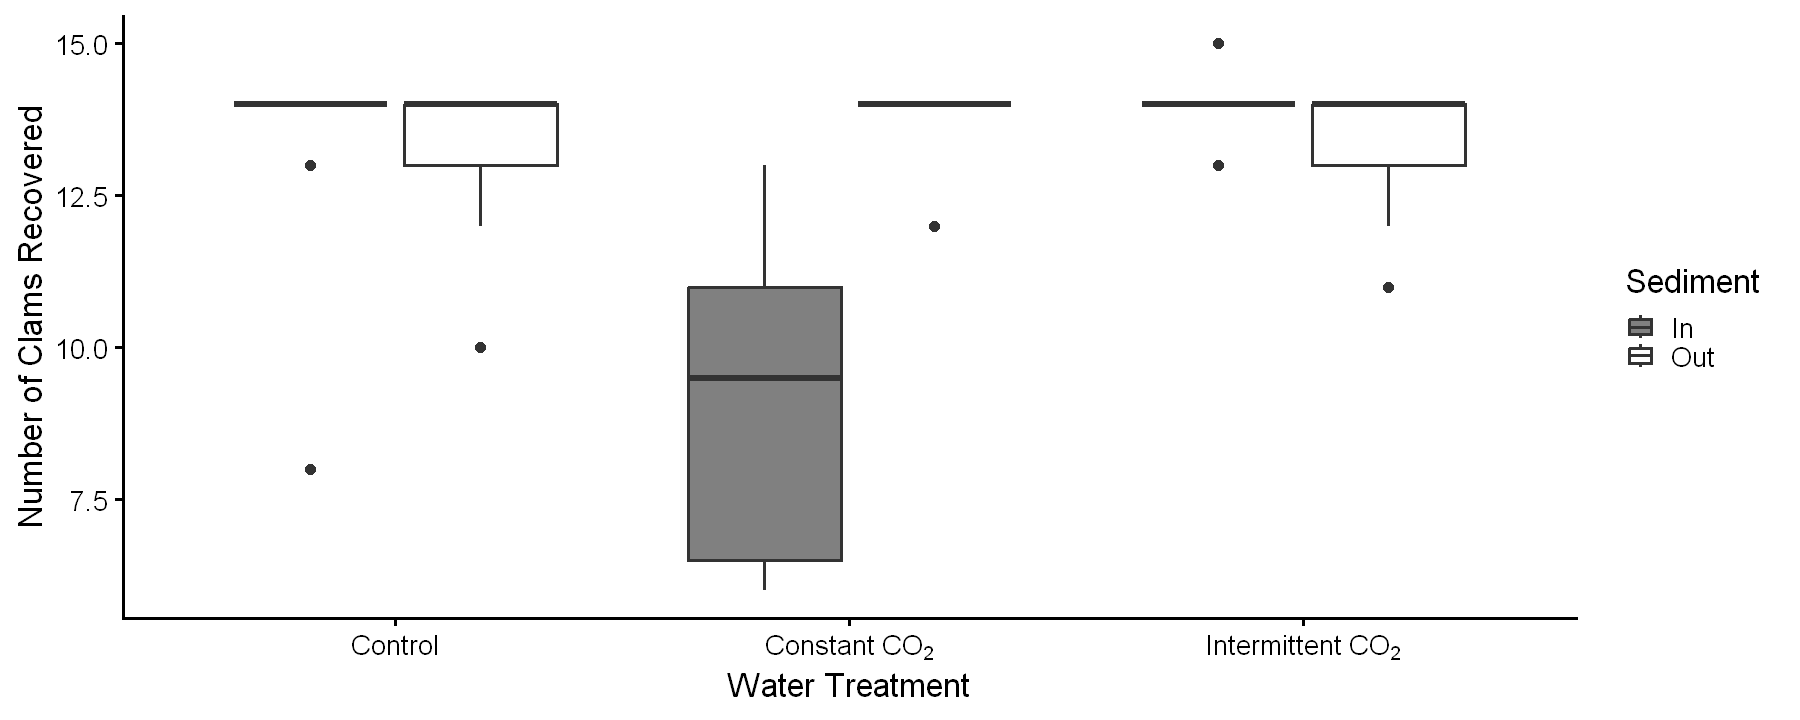

In [64]:
# ── Figure 3: Survival ────────────────────────────────────────────────────────
ggplot(MyaCombWeighFin3, aes(x = Water_trt, y = Indiv, fill = Sed_trt)) +
  geom_boxplot() +
  labs(x = "Water Treatment", y = "Number of Clams Recovered", fill = "Sediment") +
  scale_x_discrete(labels = water_trt_labels) +
  grey_fill + base_theme

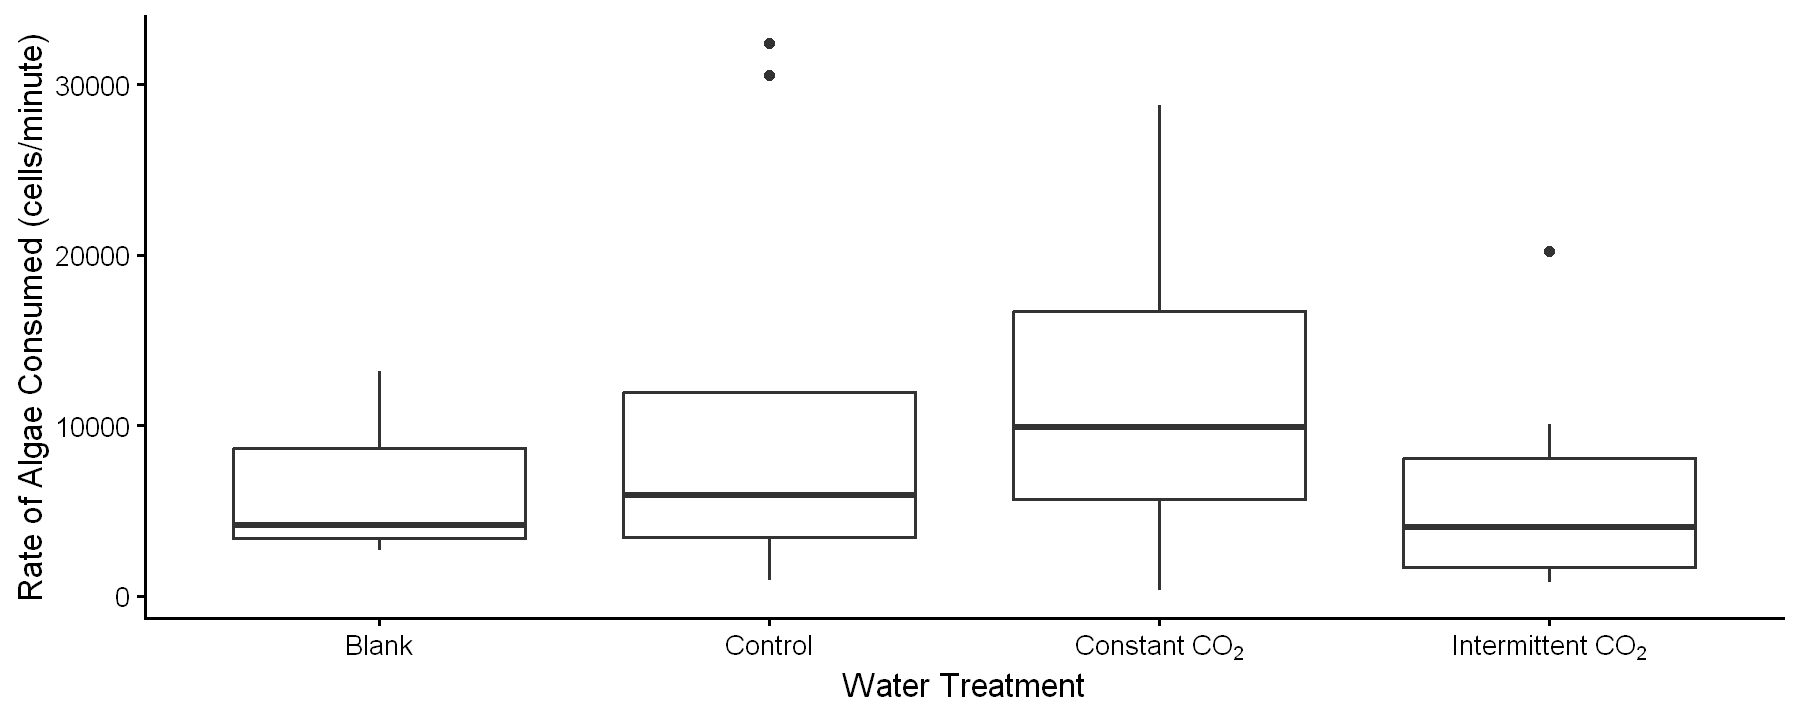

In [65]:
# ── Figure 4: Feeding rate ────────────────────────────────────────────────────
ggplot(clamFeed3, aes(x = Water_trt, y = Rate)) +
  geom_boxplot() +
  labs(x = "Water Treatment", y = "Rate of Algae Consumed (cells/minute)") +
  scale_x_discrete(labels = c(
    expression(Blank),
    expression(Control),
    expression(Constant~CO[2]),
    expression(Intermittent~CO[2])
  )) +
  base_theme

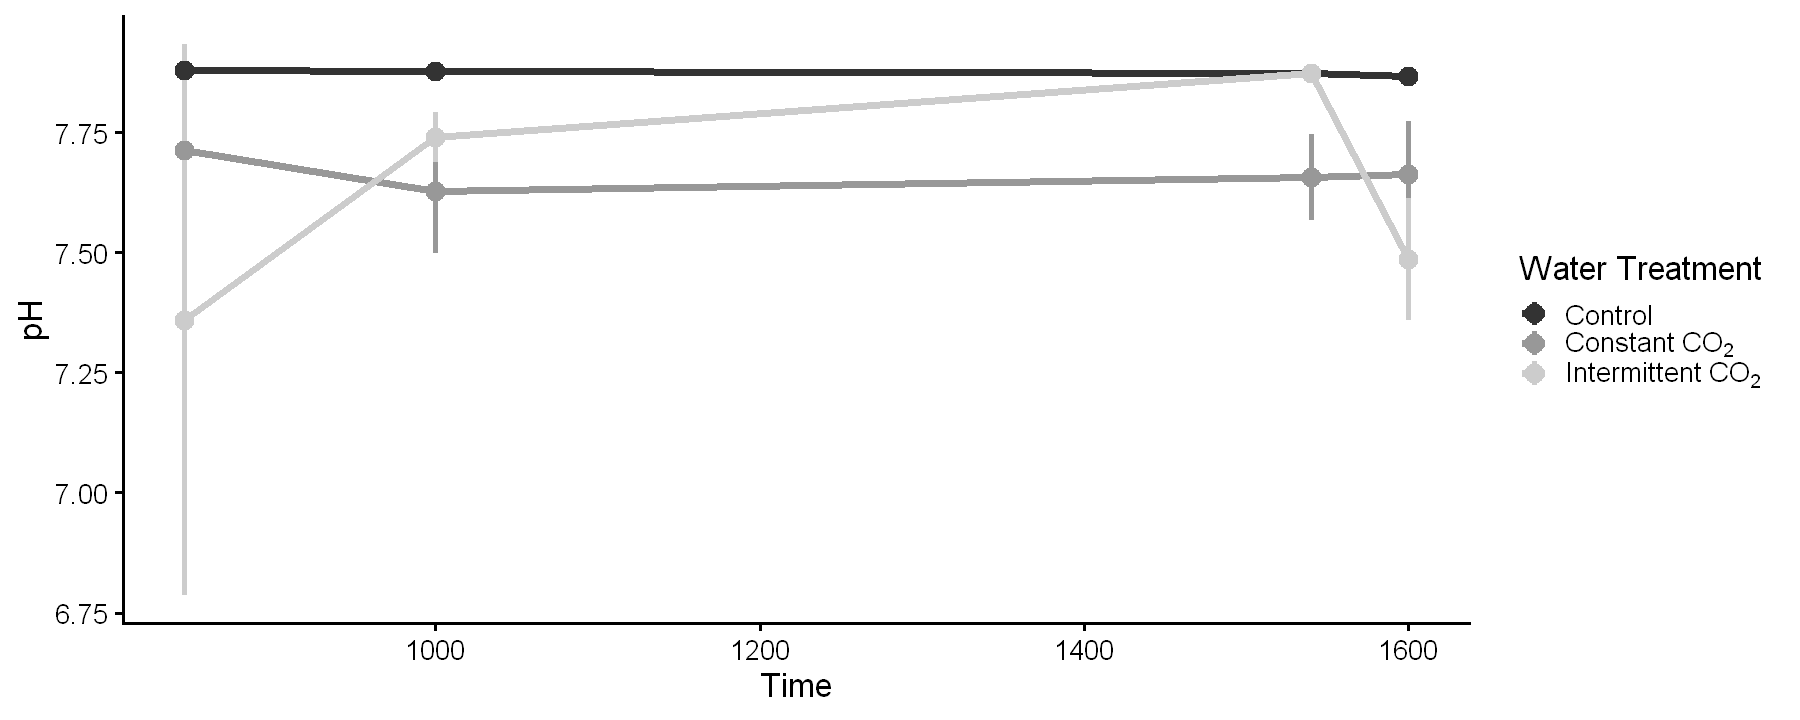

In [66]:
# ── Figure 5: pH time series (representative measurement date) ────────────────
ggplot(ph_day_summary, aes(x = Time, y = mean_pH,
                           group = Water_Trt, color = Water_Trt)) +
  geom_line(linewidth = 2) +
  geom_point(size = 4) +
  geom_pointrange(aes(ymin = mean_pH - sd_pH, ymax = mean_pH + sd_pH),
                  linewidth = 1.5) +
  labs(x = "Time", y = "pH") +
  scale_color_grey(name = "Water Treatment", labels = water_trt_labels) +
  base_theme

Warning message:
"Removed 3 rows containing non-finite outside the scale range
(`stat_boxplot()`)."


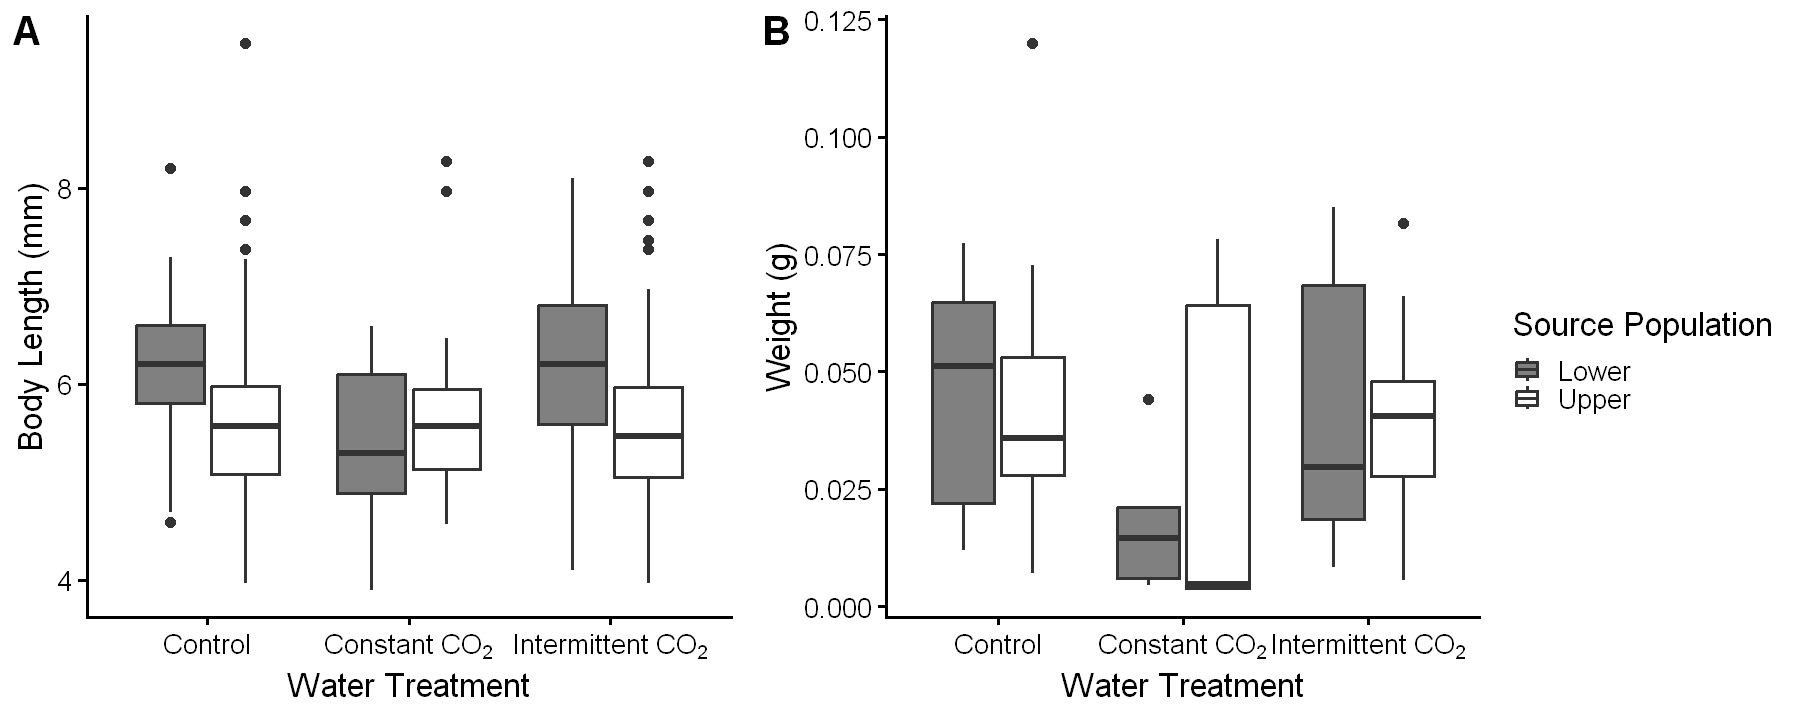

In [67]:
# ── Figure 6: Corophium length and weight ─────────────────────────────────────
fig_coroleng <- ggplot(coroLeng3, aes(x = Water_Trt, y = Length, fill = Population)) +
  geom_boxplot() +
  labs(x = "Water Treatment", y = "Body Length (mm)", fill = "Source Population") +
  scale_x_discrete(labels = water_trt_labels) +
  grey_fill + base_theme

fig_coroweigh <- ggplot(coroWeight3, aes(x = Water_Trt, y = Weight, fill = Population)) +
  geom_boxplot() +
  labs(x = "Water Treatment", y = "Weight (g)", fill = "Source Population") +
  scale_x_discrete(labels = water_trt_labels) +
  grey_fill + base_theme

ggarrange(fig_coroleng, fig_coroweigh,
          labels        = c("A", "B"),
          font.label    = list(size = 24),
          common.legend = TRUE,
          legend        = "right")

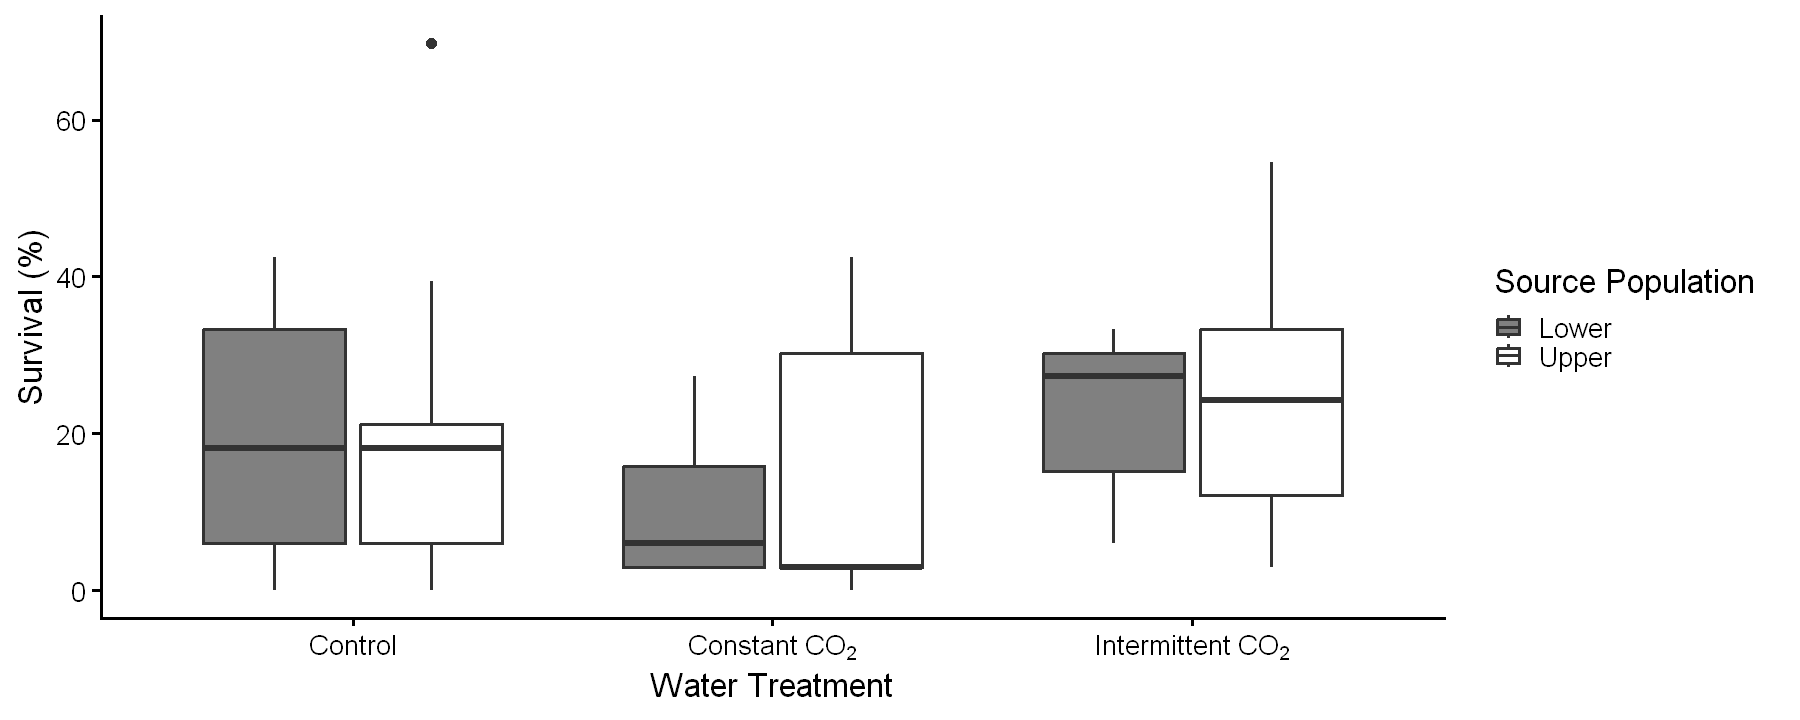

In [68]:
# ── Figure 7: Corophium survival ──────────────────────────────────────────────
ggplot(coroSurv3, aes(x = Water_Trt, y = Surv__All, fill = Population)) +
  geom_boxplot() +
  labs(x = "Water Treatment", y = "Survival (%)", fill = "Source Population") +
  scale_x_discrete(labels = water_trt_labels) +
  grey_fill + base_theme